In [5]:
# Imports and seeds

import os, random  # Import OS and random modules for environment and reproducibility

import numpy as np  # Import NumPy for numerical computations

import pandas as pd  # Import Pandas for data manipulation and analysis

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# Import functions for splitting data, k-fold cross-validation, and evaluating models

from sklearn.preprocessing import MinMaxScaler
# Import MinMaxScaler for normalizing numerical features

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
# Import various model evaluation metrics

from sklearn.tree import DecisionTreeClassifier  # Import Decision Tree classifier

from sklearn.neighbors import KNeighborsClassifier  # Import K-Nearest Neighbors classifier

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
# Import ensemble models: Random Forest and AdaBoost

from sklearn.naive_bayes import GaussianNB  # Import Gaussian Naive Bayes classifier

from sklearn.linear_model import LogisticRegression  # Import Logistic Regression classifier

from sklearn.svm import SVC  # Import Support Vector Classifier (SVM)

import matplotlib.pyplot as plt  # Import Matplotlib for plotting

import seaborn as sns  # Import Seaborn for statistical data visualization

# Reproducibility seeds
RANDOM_SEED = 42  # Define a fixed random seed value for reproducibility

np.random.seed(RANDOM_SEED)  # Set NumPy's random seed

random.seed(RANDOM_SEED)  # Set Python's built-in random seed

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)  # Set the PYTHONHASHSEED environment variable for hash reproducibility

# TensorFlow / Keras
import tensorflow as tf  # Import TensorFlow for deep learning

tf.random.set_seed(RANDOM_SEED)  # Set TensorFlow's random seed for reproducibility

from tensorflow.keras.models import Sequential  # Import Sequential model from Keras

from tensorflow.keras.layers import Dense  # Import Dense (fully connected) layer from Keras

from tensorflow.keras.optimizers import SGD  # Import Stochastic Gradient Descent optimizer from Keras


In [7]:
!unzip archive.zip

Archive:  archive.zip
  inflating: survey lung cancer1.csv  


In [8]:
DATA_PATH = "/content/survey lung cancer1.csv"

In [14]:
df = pd.read_csv(DATA_PATH)

In [16]:
df.shape

(309, 16)

In [17]:
# 1) Drop duplicates
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print("Dropped duplicates:", before - df.shape[0], "New shape:", df.shape)

# 2) Missing values
print("Missing per column:\n", df.isnull().sum())

# Fill missing if any (median for numeric, mode for others)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

# 3) Find target column automatically
target_col = None
for c in df.columns:
    if c.lower().replace(" ", "_") in ["lung_cancer", "lung_cancer", "lungcancer", "cancer"]:
        target_col = c
        break
# Fallback to exact name 'Lung_Cancer'
if target_col is None and 'Lung_Cancer' in df.columns:
    target_col = 'Lung_Cancer'

if target_col is None:
    print("Columns:", df.columns.tolist())
    raise ValueError("Could not find target column automatically. Edit the code to set 'target_col'.")

print("Target column:", target_col, "unique values:", df[target_col].unique())

# Map target to binary 1 (positive) and 0 (negative) - paper used 1 & 2
def map_target(vals):
    s = pd.Series(vals)
    unique = list(s.unique())
    if set(unique) <= set([1,2,'1','2']):
        return s.replace({2:0, '2':0})
    if any(str(x).lower().startswith('y') for x in unique):
        return s.apply(lambda x: 1 if str(x).lower().startswith('y') else 0)
    if any(str(x).lower().startswith('p') for x in unique):
        return s.apply(lambda x: 1 if str(x).lower().startswith('p') else 0)
    # fallback numeric
    try:
        s = pd.to_numeric(s)
        return s.apply(lambda x: 1 if x==1 else 0)
    except:
        raise ValueError("Unknown target value types: " + str(unique))

df[target_col] = map_target(df[target_col])
print(df[target_col].value_counts())


Dropped duplicates: 33 New shape: (276, 16)
Missing per column:
 GENDER                    0
AGE                       0
SMOKING                   0
YELLOW_FINGERS            0
ANXIETY                   0
PEER_PRESSURE             0
CHRONIC_DISEASE           0
FATIGUE                   0
ALLERGY                   0
WHEEZING                  0
ALCOHOL _CONSUMING        0
COUGHING                  0
SHORTNESS _OF_BREATH      0
SWALLOWING _DIFFICULTY    0
CHEST_PAIN                0
LUNG_CANCER               0
dtype: int64
Target column: LUNG_CANCER unique values: ['YES' 'NO']
LUNG_CANCER
1    238
0     38
Name: count, dtype: int64


In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target_col]
print("Numeric columns:", numeric_cols)

def remove_iqr_outliers(df, cols):
    df2 = df.copy()
    outlier_mask = pd.Series(False, index=df2.index)
    for col in cols:
        Q1 = df2[col].quantile(0.25)
        Q3 = df2[col].quantile(0.75)
        IQR = Q3 - Q1
        low = Q1 - 1.5 * IQR
        high = Q3 + 1.5 * IQR
        outlier_mask = outlier_mask | (df2[col] < low) | (df2[col] > high)
    n = outlier_mask.sum()
    if n > 0:
        print("Outliers found:", n, "Removing them.")
        df2 = df2.loc[~outlier_mask].reset_index(drop=True)
    else:
        print("No IQR outliers found.")
    return df2

df = remove_iqr_outliers(df, numeric_cols)
print("Shape after outlier removal:", df.shape)


Numeric columns: ['AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC_DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING', 'ALCOHOL _CONSUMING', 'COUGHING', 'SHORTNESS _OF_BREATH', 'SWALLOWING _DIFFICULTY', 'CHEST_PAIN']
Outliers found: 4 Removing them.
Shape after outlier removal: (272, 16)


In [21]:
corrs = {}
for col in df.columns:
    if col == target_col:
        continue
    try:
        # Attempt to calculate correlation directly if the column is numeric
        r = df[col].astype(float).corr(df[target_col].astype(float))
    except (ValueError, TypeError):
        # If direct conversion fails (e.g., for non-numeric columns), factorize and then calculate correlation
        # pd.factorize returns a tuple (array, index), we need the array
        factored_col, _ = pd.factorize(df[col])
        r = pd.Series(factored_col).astype(float).corr(df[target_col].astype(float))
    corrs[col] = r

corr_df = pd.DataFrame.from_dict(corrs, orient='index', columns=['pearson_r']).sort_values(by='pearson_r', ascending=False)
print(corr_df)

THRESH = 0.15
selected_features = corr_df[abs(corr_df['pearson_r']) >= THRESH].index.tolist()
print("Selected features (|r|>={:.2f}): {}".format(THRESH, selected_features))

# If you want to force the five named features from paper uncomment:
# selected_features = ['Coughing','Wheezing','Alcohol_Consuming','Swallowing_Difficulty','Allergy']

                        pearson_r
ALLERGY                  0.339560
ALCOHOL _CONSUMING       0.283486
SWALLOWING _DIFFICULTY   0.262321
COUGHING                 0.239925
WHEEZING                 0.233687
PEER_PRESSURE            0.182245
CHEST_PAIN               0.177370
FATIGUE                  0.175908
YELLOW_FINGERS           0.173962
CHRONIC_DISEASE          0.166359
ANXIETY                  0.133064
AGE                      0.107680
SHORTNESS _OF_BREATH     0.078434
SMOKING                  0.034597
GENDER                  -0.036082
Selected features (|r|>=0.15): ['ALLERGY ', 'ALCOHOL _CONSUMING', 'SWALLOWING _DIFFICULTY', 'COUGHING', 'WHEEZING', 'PEER_PRESSURE', 'CHEST_PAIN', 'FATIGUE ', 'YELLOW_FINGERS', 'CHRONIC_DISEASE']


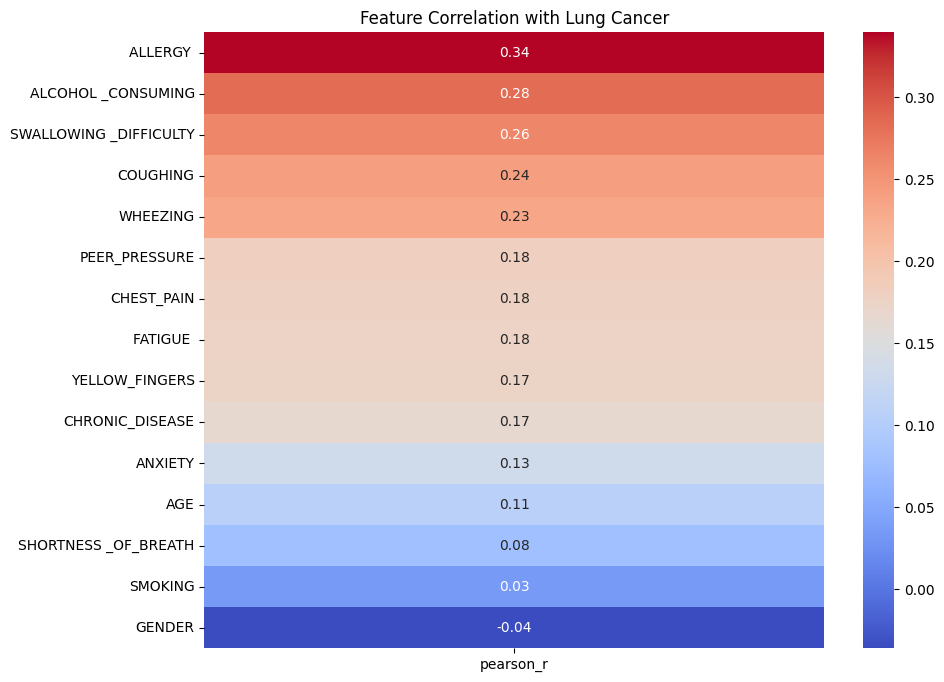

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation with Lung Cancer")
plt.show()

In [22]:
X = df[selected_features].copy()
y = df[target_col].copy()

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()


,ALLERGY,ALCOHOL _CONSUMING,SWALLOWING _DIFFICULTY,COUGHING,WHEEZING,PEER_PRESSURE,CHEST_PAIN,FATIGUE,YELLOW_FINGERS,CHRONIC_DISEASE
0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
3,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED)
print("Train:", X_train.shape, "Test:", X_test.shape)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

classifiers = {
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_SEED),
    'KNN_k7': KNeighborsClassifier(n_neighbors=7),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'NaiveBayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_SEED),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'SVM': SVC(probability=True, random_state=RANDOM_SEED)
}


Train: (217, 10) Test: (55, 10)


In [24]:
def compute_metrics(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = None
    if y_prob is not None:
        try:
            auc = roc_auc_score(y_true, y_prob)
        except:
            auc = None
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}

results = {}
for name, clf in classifiers.items():
    print("Evaluating:", name)
    try:
        cv_scores = cross_val_score(clf, X_scaled, y, cv=skf, scoring='accuracy')
        cv_acc = cv_scores.mean()
    except Exception as e:
        print("CV error:", e)
        cv_acc = None
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = None
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_test)[:,1]
    elif hasattr(clf, "decision_function"):
        try:
            y_prob = clf.decision_function(X_test)
        except:
            y_prob = None
    metrics = compute_metrics(y_test, y_pred, y_prob)
    results[name] = {'cv_acc': cv_acc, 'test_metrics': metrics}
    print(f"CV acc: {cv_acc} | Test acc: {metrics['accuracy']:.4f} | prec: {metrics['precision']:.4f} | rec: {metrics['recall']:.4f} | f1: {metrics['f1']:.4f} | auc: {metrics['auc']}")


Evaluating: DecisionTree
CV acc: 0.8564814814814815 | Test acc: 0.8727 | prec: 0.9184 | rec: 0.9375 | f1: 0.9278 | auc: 0.8839285714285714
Evaluating: KNN_k7
CV acc: 0.9002645502645503 | Test acc: 0.8909 | prec: 0.9038 | rec: 0.9792 | f1: 0.9400 | auc: 0.949404761904762
Evaluating: RandomForest
CV acc: 0.8785714285714284 | Test acc: 0.8909 | prec: 0.9038 | rec: 0.9792 | f1: 0.9400 | auc: 0.9702380952380952
Evaluating: NaiveBayes
CV acc: 0.8932539682539684 | Test acc: 0.9636 | prec: 0.9792 | rec: 0.9792 | f1: 0.9792 | auc: 0.9880952380952381
Evaluating: AdaBoost
CV acc: 0.9076719576719577 | Test acc: 0.9091 | prec: 0.9216 | rec: 0.9792 | f1: 0.9495 | auc: 0.9523809523809523
Evaluating: LogisticRegression
CV acc: 0.9076719576719576 | Test acc: 0.9273 | prec: 0.9231 | rec: 1.0000 | f1: 0.9600 | auc: 0.9732142857142856
Evaluating: SVM
CV acc: 0.896957671957672 | Test acc: 0.9091 | prec: 0.9216 | rec: 0.9792 | f1: 0.9495 | auc: 0.9553571428571428


In [25]:
input_dim = X_train.shape[1]

def build_nn_model(arch='1hidden', input_dim=8, lr=0.01):
    model = Sequential()
    if arch == '1hidden':
        model.add(Dense(units=8, activation='relu', input_shape=(input_dim,)))
        model.add(Dense(units=8, activation='relu'))
        model.add(Dense(units=1, activation='sigmoid'))
    elif arch == '2hidden':
        model.add(Dense(units=8, activation='relu', input_shape=(input_dim,)))
        model.add(Dense(units=41, activation='relu'))
        model.add(Dense(units=8, activation='relu'))
        model.add(Dense(units=1, activation='sigmoid'))
    elif arch == '3hidden':
        model.add(Dense(units=8, activation='relu', input_shape=(input_dim,)))
        model.add(Dense(units=25, activation='relu'))
        model.add(Dense(units=16, activation='relu'))
        model.add(Dense(units=8, activation='relu'))
        model.add(Dense(units=1, activation='sigmoid'))
    else:
        raise ValueError("Unknown arch")
    optimizer = SGD(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Quick test run (reduce epochs for speed)
arch = '1hidden'   # try '2hidden', '3hidden'
lr = 0.1
epochs = 50  # quick check; increase to 200/400/800 for full runs
model = build_nn_model(arch=arch, input_dim=input_dim, lr=lr)
history = model.fit(X_train.values, y_train.values, epochs=epochs, batch_size=16, validation_split=0.1, verbose=1)
y_prob = model.predict(X_test.values).ravel()
y_pred = (y_prob >= 0.5).astype(int)
metrics = compute_metrics(y_test, y_pred, y_prob)
print("NN metrics:", metrics)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.6392 - loss: 0.6332 - val_accuracy: 1.0000 - val_loss: 0.3065
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8533 - loss: 0.4173 - val_accuracy: 1.0000 - val_loss: 0.1806
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8533 - loss: 0.3714 - val_accuracy: 1.0000 - val_loss: 0.1472
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8533 - loss: 0.3579 - val_accuracy: 1.0000 - val_loss: 0.1374
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8533 - loss: 0.3490 - val_accuracy: 1.0000 - val_loss: 0.1345
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8533 - loss: 0.3413 - val_accuracy: 1.0000 - val_loss: 0.1332
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8533 - loss: 0.3335 - val_accuracy: 1.0000 - val_loss: 0.1309
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8533 - loss: 0.3258 - val_accuracy: 1.0000 - v

In [26]:
# Save ML summary CSV
ml_summary = []
for name, res in results.items():
    tm = res['test_metrics']
    ml_summary.append({
        'model': name,
        'cv_acc': res['cv_acc'],
        'test_acc': tm['accuracy'],
        'precision': tm['precision'],
        'recall': tm['recall'],
        'f1': tm['f1'],
        'auc': tm['auc']
    })
ml_df = pd.DataFrame(ml_summary)
save_path = "/content/drive/MyDrive/lung_project_results"  # adjust if you want different Drive folder
os.makedirs(save_path, exist_ok=True)
ml_df.to_csv(os.path.join(save_path, "ml_results_summary.csv"), index=False)
print("Saved ML summary to", os.path.join(save_path, "ml_results_summary.csv"))

# Save NN metrics from quick run (example)
nn_metrics_example = metrics
pd.DataFrame([nn_metrics_example]).to_csv(os.path.join(save_path, "nn_example_metrics.csv"), index=False)
print("Saved NN example metrics.")


Saved ML summary to /content/drive/MyDrive/lung_project_results/ml_results_summary.csv
Saved NN example metrics.


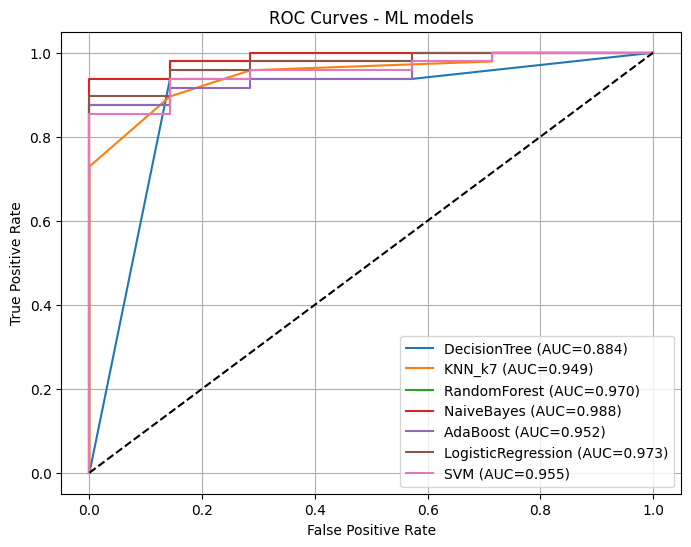

In [27]:
plt.figure(figsize=(8,6))
for name, clf in classifiers.items():
    try:
        prob = clf.predict_proba(X_test)[:,1]
    except:
        try:
            prob = clf.decision_function(X_test)
            prob = (prob - prob.min()) / (prob.max() - prob.min() + 1e-9)
        except:
            prob = None
    if prob is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_v = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_v:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - ML models")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [29]:
learning_rates = [0.1, 0.01, 0.005]
epoch_list = [200, 400, 800]
architectures = ['1hidden', '2hidden', '3hidden']

nn_results = {}
for arch in architectures:
    for lr in learning_rates:
        for epochs in epoch_list:
            key = f"{arch}_lr{lr}_ep{epochs}"
            print("Running:", key)
            model = build_nn_model(arch=arch, input_dim=input_dim, lr=lr)
            model.fit(X_train.values, y_train.values, epochs=epochs, batch_size=16, verbose=0, validation_split=0.1)
            y_prob = model.predict(X_test.values).ravel()
            y_pred = (y_prob >= 0.5).astype(int)
            nn_results[key] = compute_metrics(y_test, y_pred, y_prob)
            print(key, nn_results[key])
            tf.keras.backend.clear_session()

# Save NN results to Drive
pd.DataFrame([{'experiment':k, **v} for k,v in nn_results.items()]).to_csv(os.path.join(save_path, "nn_results_full.csv"), index=False)
print("Saved full NN results to Drive.")


Running: 1hidden_lr0.1_ep200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1hidden_lr0.1_ep200 {'accuracy': 0.9272727272727272, 'precision': 0.9230769230769231, 'recall': 1.0, 'f1': 0.96, 'auc': np.float64(0.9732142857142857)}
Running: 1hidden_lr0.1_ep400


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1hidden_lr0.1_ep400 {'accuracy': 0.8909090909090909, 'precision': 0.9038461538461539, 'recall': 0.9791666666666666, 'f1': 0.94, 'auc': np.float64(0.9702380952380952)}
Running: 1hidden_lr0.1_ep800


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
3hidden_lr0.005_ep200 {'accuracy': 0.9272727272727272, 'precision': 0.9230769230769231, 'recall': 1.0, 'f1': 0.96, 'auc': np.float64(0.988095238095238)}
Running: 3hidden_lr0.005_ep400


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
3hidden_lr0.005_ep400 {'accuracy': 0.9636363636363636, 'precision': 0.96, 'recall': 1.0, 'f1': 0.9795918367346939, 'auc': np.float64(0.9880952380952381)}
Running: 3hidden_lr0.005_ep800


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
3hidden_lr0.005_ep800 {'accuracy': 0.8545454545454545, 'precision': 0.9166666666666666, 'recall': 0.9166666666666666, 'f1': 0.9166666666666666, 'auc': np.float64(0.9255952380952381)}
Saved full NN results to Drive.


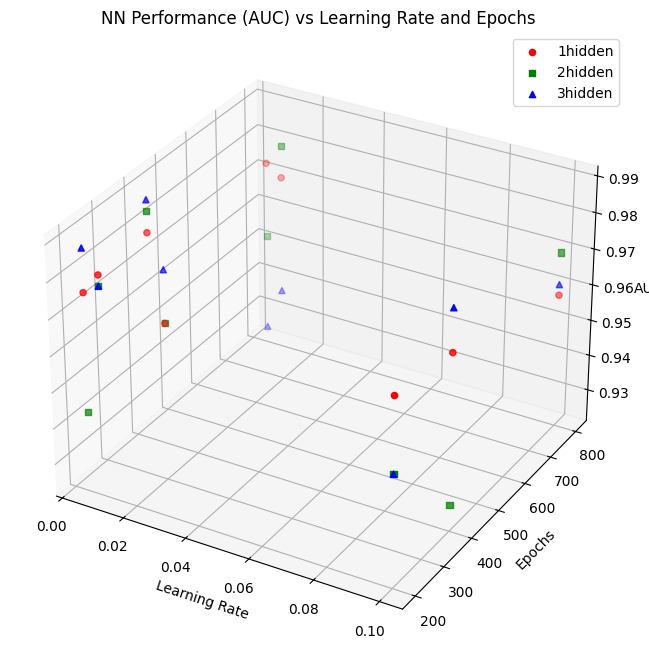

In [30]:
from mpl_toolkits.mplot3d import Axes3D

# Extract data for plotting
plot_data = []
for key, metrics in nn_results.items():
    arch, lr_ep = key.split('_lr')
    lr, ep = lr_ep.split('_ep')
    plot_data.append({'arch': arch, 'lr': float(lr), 'epochs': int(ep), 'auc': metrics['auc']})

plot_df = pd.DataFrame(plot_data)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'1hidden': 'r', '2hidden': 'g', '3hidden': 'b'}
markers = {'1hidden': 'o', '2hidden': 's', '3hidden': '^'}

for arch, group in plot_df.groupby('arch'):
    ax.scatter(group['lr'], group['epochs'], group['auc'], c=colors[arch], marker=markers[arch], label=arch)

ax.set_xlabel('Learning Rate')
ax.set_ylabel('Epochs')
ax.set_zlabel('AUC')
ax.set_title('NN Performance (AUC) vs Learning Rate and Epochs')
ax.legend()
plt.show()